# Parcial numero uno de fisica computacional 1 - Universidad de Antioquia - Instituto de Fisica
CC: 1004998829

### 1) Haga una expansion en series de Taylor de orden cuatro, alrededor de x=0, para la siguiente funcion:
$$ f(x) = -0.1x^{4} - 0.15x^{3} - 0.5x^{2} - 0.25x + 1.2$$

Solucion: En un principio podemos notar que la funcion ya es un polinomio de grado 4, por lo que su expansion en series de taylor es la misma expresion. Sin embargo, vamos a realizar la verificacion usando calculo simbolico en python y graficando ambas funciones.

Recordemos que el cocepto fundamental de la expancion en taylor es:
$$f(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(a)}{n!}(x-a)^n = f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \frac{f'''(a)}{3!}(x-a)^3 + \cdots$$

In [3]:
# Importamos librerias necesarias
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt


# Empezamos a definir variables y la propia funicion
x = sp.symbols('x')
f = -0.1*x**4 - 0.15*x**3 - 0.5*x**2 - 0.25*x + 1.2

# ahora vamos a hacer la exapnsion en series de taylor paso a paso, por cada orden vamos imprimiendo el resultado
taylor_0 = f.subs(x, 0)
print(f"Taylor order 0: {taylor_0}")
taylor_1 = taylor_0 + f.diff(x).subs(x, 0)*x
print(f"Taylor order 1: {taylor_1}")
taylor_2 = taylor_1 + f.diff(x, 2).subs(x, 0)*x**2/sp.factorial(2)
print(f"Taylor order 2: {taylor_2}")
taylor_3 = taylor_2 + f.diff(x, 3).subs(x, 0)*x**3/sp.factorial(3)
print(f"Taylor order 3: {taylor_3}")
taylor_4 = taylor_3 + f.diff(x, 4).subs(x, 0)*x**4/sp.factorial(4)
print(f"Taylor order 4: {taylor_4}")

print("Funcion original:", f)

Taylor order 0: 1.20000000000000
Taylor order 1: 1.2 - 0.25*x
Taylor order 2: -0.5*x**2 - 0.25*x + 1.2
Taylor order 3: -0.15*x**3 - 0.5*x**2 - 0.25*x + 1.2
Taylor order 4: -0.1*x**4 - 0.15*x**3 - 0.5*x**2 - 0.25*x + 1.2
Funcion original: -0.1*x**4 - 0.15*x**3 - 0.5*x**2 - 0.25*x + 1.2


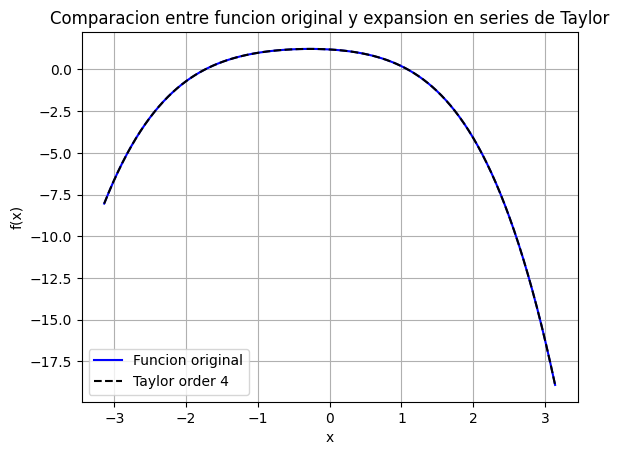

In [8]:
# ahora vamos a graficar la original y la expansion de taylor al rededor de x=0
val_x = np.linspace(-np.pi, np.pi, 100)

# Vamos a graficar ambas funciones
plt.plot(val_x, [f.subs(x, val).evalf() for val in val_x], label='Funcion original', color='blue')
plt.plot(val_x, [taylor_4.subs(x, val).evalf() for val in val_x], label='Taylor order 4', color='black', linestyle='--')
plt.legend()
plt.title('Comparacion entre funcion original y expansion en series de Taylor')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.show()

Conclusion: Notamos que evidentemente ambas funciones son las misma.

### 2) Calcule las aproximaciones por diferencias hacia delante, hacia atras y  aproximaciones por diferencia central para la primera derivada de la función del numeral anterior con un paso de $h=0.25$. Estime el error relativo porcentual para cada aproximacion.

Solución: Ya tenemos definida la funcion de forma analitica, por comodidad la vamos a 'lambdificar' para hacer mas facil su evalaucion numerica. Por otro lado vamos a recordar cuales son las definiciones de las aproximaciones por diferencias:
- Diferencias hacia delante:
$$f'(x) \approx \frac{f(x+h) - f(x)}{h} $$
- Diferencias hacia atras:
$$f'(x) \approx \frac{f(x) - f(x-h)}{h}$$
- Diferencias centrales:
$$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$$

Recordemos que la funcion es $$ f(x) = -0.1x^{4} - 0.15x^{3} - 0.5x^{2} - 0.25x + 1.2$$ y por lo tanto su derivada es: $$ f(x) = -0.4x^{3} - 0.45x^{2} -x - 0.25$$

In [14]:
# tenemos la funcion f y la vamos a lambdificar
f = lambda x: -0.1*x**4 - 0.15*x**3 - 0.5*x**2 - 0.25*x + 1.2
# Definimos los parametros:
h = 0.25
x0 = 2

# Definimos la derivada ezxacta con el fin de comparar
f_ex = lambda x: -0.4*x**3 - 0.45*x**2 -x -0.25

# ahora definimos los metodos de diferenciacion
# adelante
adelante = (f(x0 + h) - f(x0)) / h
# atras
atras = (f(x0) - f(x0 - h)) / h
# central
central = (f(x0 + h) - f(x0 - h)) / (2*h)

# el valor verdadero de la derivada en x0
valor_verdadero = f_ex(x0)

# calculamos los errores relativos definiendo una funcion general
def error_rel(aprox, verdad):
    return abs((verdad - aprox) / verdad) * 100

# calculamos los errores relativos
error_adelante = error_rel(adelante, valor_verdadero)
error_atras = error_rel(atras, valor_verdadero)
error_central = error_rel(central, valor_verdadero)

# imprimimos los resultados:

print(f"Valor verdadero de f'(2): {valor_verdadero:.2g}")
print(f"Derivando hacia adelante: {adelante:.2g}, con un error de {error_adelante:.2g}%")
print(f"Derivando hacia atras: {atras:.2g}, con un error de {error_atras:.2g}%")
print(f"Derivando central: {central:.2g}, con un error de {error_central:.2g}%")

Valor verdadero de f'(2): -7.2
Derivando hacia adelante: -8.3, con un error de 14%
Derivando hacia atras: -6.4, con un error de 12%
Derivando central: -7.3, con un error de 0.82%


Conclusion: Notamos que de los tres metodos, que tuvo mejor desempeño fue el de derivar centralmente, lo cual se ajusta a lo visto en clase.

### 3) Aplicar el método de Euler para aproximar la caída libre de un cuerpo que es soltado desde una altura de $100 m$. Comparar los resultados con la solución analítica y con la aproximación de Euler.

Solucion: Recordemos que el metodo de euler es un metodo iterativo donde:
$f(t, y)$ es la pendiente de la curva solución en el punto $(t, y)$.

Partiendo de $(t_n, y_n)$, avanzamos un paso $h$ en dirección de la pendiente:
$$y_{n+1} = y_n + h \cdot f(t_n, y_n)$$

Para este ejercicio en especifico la situacion plantateada es $\ddot y=-g$, $y(0)=100$ m, $v(0)=0$ m/s, con $g=9.81$ m/s². 
Del calculo conocemos que la analitica para la posicion y velocidad es:
$$ y(t) = y_0 + v_0 t - \frac{1}{2} g t^2 $$
$$ v(t) = v_0 - g t $$
y aplicando las condiciones iniciales:
$$ y(t) = 100 - \frac{1}{2} g t^2 $$

Siendo asi que el tiempo que tarda en llegar al suelo es:
$$ t = \sqrt{\frac{2 y_0}{g}} $$

Notamos que para el metodo de euler, las iteraciones son:
$$ v_{n+1} = v_n - g \cdot h $$
$$ y_{n+1} = y_n + v_n \cdot h $$

In [20]:
# Vamos a definir los paramentro de la caida libre
g = 9.81  
h = 0.1
y0 = 100
v0 = 0

# Ahora vamos a definir el metodo de euler para resolver
def euler(y0, v0, g, h, tmax=12):
    t = [0.0] # leemos las variables
    y = [y0]
    v = [v0]
    nmax = int(tmax/h) #definimos el numero maximo de iteraciones para que no dicverja
    for n in range(nmax):
        v_new = v[-1] - g*h  # definimos los volres usando los varoes pasados
        y_new = y[-1] + v[-1]*h
        t_new = t[-1] + h
        v.append(v_new)
        y.append(y_new)
        t.append(t_new)
        if y_new <= 0.0:
            break
    t = np.array(t)
    y = np.array(y)
    v = np.array(v)
    if y[-1] > 0:
        t_impact = np.nan
    else:
        t_impact = t[-2] + (0 - y[-2])*(t[-1]-t[-2])/(y[-1]-y[-2])
    return t, y, v, t_impact


# Calculamos el tiempo analitico para comparar
t_analitico = np.sqrt(2*y0/g)
# asi mismo definimos la expresion lambda para la posicion analitica
y_analitica = lambda t: y0 - 0.5*g*t**2

# evaluamos el metodo de euler
t_euler, y_euler, v_euler, t_impact_euler = euler(y0, v0, g, h)

print(f"Tiempo de caida analitico {t_analitico:.2g} s")
print(f"Tiempo de caida con euler {t_impact_euler:.2g} s")
print(f"Error porcentual:{error_rel(t_impact_euler, t_analitico):.2g} %")


Tiempo de caida analitico 4.5 s
Tiempo de caida con euler 4.6 s
Error porcentual:1.1 %


Conclusion: Notamos que el metodo de euler es muy cercano con un error estimado del 1.1%

### 4) Utilizar el método de Runge-Kutta de orden cuatro para aproximar la solución de: $$ Y' = Y - t^{2} +1 $$ Para 0< t < 2, con y(0) = 0.5, y un paso de h=0.5.

Recordemos que el metodo de runge-kuta de orden 4 esta definido por:
Dado $y' = f(t, y)$ con $y(t_0) = y_0$, el método RK4 avanza de $(t_n, y_n)$ a $(t_{n+1}, y_{n+1})$ mediante:

$$\boxed{y_{n+1} = y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)}$$

donde:
$$\begin{aligned}
k_1 &= f(t_n, y_n) \\
k_2 &= f\left(t_n + \frac{h}{2}, y_n + \frac{h}{2}k_1\right) \\
k_3 &= f\left(t_n + \frac{h}{2}, y_n + \frac{h}{2}k_2\right) \\
k_4 &= f(t_n + h, y_n + h k_3)
\end{aligned}$$

Paso h = 0.5

t		y(RK4)		y(exacta)	Error
------------------------------------------------------------
0.0		0.500000	0.500000	0.00e+00
0.5		1.425130	1.425639	5.09e-04
1.0		2.639603	2.640859	1.26e-03
1.5		4.006819	4.009155	2.34e-03
2.0		5.301605	5.305472	3.87e-03


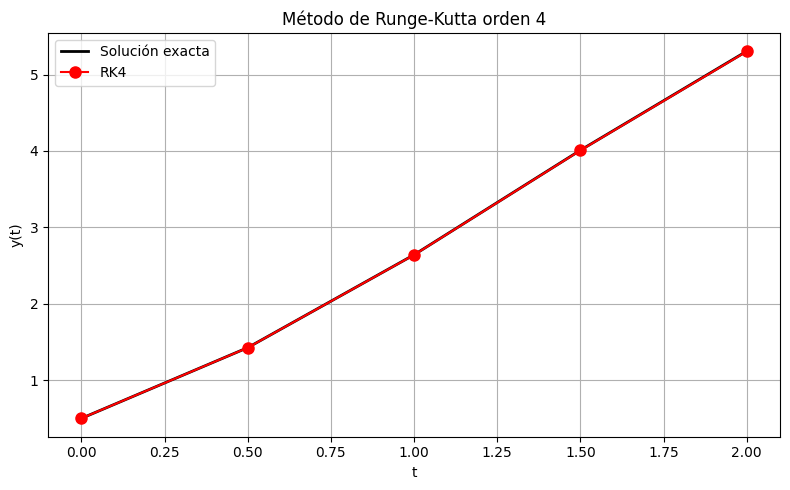

In [29]:
# Definir la función f(t, y) = y - t^2 + 1
f = lambda t, y: y - t**2 + 1

# Condiciones iniciales y parámetros
t0, y0 = 0, 0.5
t_final = 2.0
h = 0.5
n = int((t_final - t0) / h)

# Implementación del método RK4
def rk4(f, t0, y0, h, n):
    t = np.zeros(n + 1)
    y = np.zeros(n + 1)
    t[0] = t0
    y[0] = y0
    
    for i in range(n):
        k1 = f(t[i], y[i])
        k2 = f(t[i] + h/2, y[i] + h*k1/2)
        k3 = f(t[i] + h/2, y[i] + h*k2/2)
        k4 = f(t[i] + h, y[i] + h*k3)
        
        y[i+1] = y[i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        t[i+1] = t[i] + h
    
    return t, y

# Resolver con RK4
t_rk, y_rk = rk4(f, t0, y0, h, n)

# Solución analítica: y(t) = t^2 + 2t + 1 - 0.5*e^t
y_analitica = lambda t: t**2 + 2*t + 1 - 0.5*np.exp(t)
y_exacta = y_analitica(t_rk)

# Mostrar resultados
print(f"Paso h = {h}")
print("\nt\t\ty(RK4)\t\ty(exacta)\tError")
print("-" * 60)
for i in range(len(t_rk)):
    error = abs(y_rk[i] - y_exacta[i])
    print(f"{t_rk[i]:.1f}\t\t{y_rk[i]:.6f}\t{y_exacta[i]:.6f}\t{error:.2e}")

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(t_rk, y_exacta, 'k-', label='Solución exacta', linewidth=2)
plt.plot(t_rk, y_rk, 'ro-', label='RK4', markersize=8)
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Método de Runge-Kutta orden 4')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Conclusion: NOtamos que runge-kuta resuleve apropiadamente la edo.